In [ ]:
import os
import subprocess
import zipfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.freesurfer.mghformat import MGHImage

In [ ]:
# --------------------------------------------------
# Config
# --------------------------------------------------
REMOTE_BASE = "/SBM"
OUTDIR = Path("fsgd")
TMPDIR = Path("tmp_sbm")
LH_DIR = TMPDIR / "lh"
RH_DIR = TMPDIR / "rh"

OUTDIR.mkdir(exist_ok=True, parents=True)
LH_DIR.mkdir(exist_ok=True, parents=True)
RH_DIR.mkdir(exist_ok=True, parents=True)

# --------------------------------------------------
# 1) Load and prepare dataframe
# --------------------------------------------------
df_fname = "./GWAS/main/master_gwas.tsv"
subprocess.run(["dx", "download", df_fname, "-o", "master.tsv"], check=True)

df = pd.read_csv("master.tsv", sep="\t")
df = df[["subjects", "age", "sex", "srt", "eTIV", "tin_status"]].copy()
df["subjects"] = df["subjects"].astype(str)

# map group labels for FSGD
df["tin_status"] = df["tin_status"].map({0: "CO", 1: "TI"})

# optional but recommended: center continuous covariates
for col in ["age", "srt", "eTIV"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col] - df[col].mean()

# if sex is strings, uncomment and adapt:
# df["sex"] = df["sex"].map({"M": 0, "F": 1})

# --------------------------------------------------
# 2) Find common subjects
# --------------------------------------------------
result = subprocess.run(
    ["dx", "ls", REMOTE_BASE],
    capture_output=True,
    text=True,
    check=True
)

processed_subjects = {
    line.rstrip("/").strip()
    for line in result.stdout.splitlines()
    if line.strip().endswith("/")
}

common_subjects = [s for s in df["subjects"].tolist() if s in processed_subjects]
print(f"Found {len(common_subjects)} common subjects")

df = df[df["subjects"].isin(common_subjects)].copy()
df["subjects"] = pd.Categorical(df["subjects"], categories=common_subjects, ordered=True)
df = df.sort_values("subjects").reset_index(drop=True)
df["subjects"] = df["subjects"].astype(str)

# drop rows with missing values in required columns
df = df.dropna(subset=["subjects", "age", "sex", "srt", "eTIV", "tin_status"]).copy()

# --------------------------------------------------
# 3) Parallel download
# --------------------------------------------------
def download_one(subj: str):
    lh_remote = f"{REMOTE_BASE}/{subj}/surf/lh.thickness.fwhm10.fsaverage.mgh"
    rh_remote = f"{REMOTE_BASE}/{subj}/surf/rh.thickness.fwhm10.fsaverage.mgh"

    lh_local = LH_DIR / f"{subj}.lh.mgh"
    rh_local = RH_DIR / f"{subj}.rh.mgh"

    try:
        subprocess.run(
            ["dx", "download", lh_remote, "-o", str(lh_local)],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        subprocess.run(
            ["dx", "download", rh_remote, "-o", str(rh_local)],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        return subj, True, None
    except subprocess.CalledProcessError as e:
        return subj, False, str(e)

max_workers = min(16, max(4, (os.cpu_count() or 8)))
downloaded = []
failed = []

with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(download_one, subj): subj for subj in df["subjects"]}
    for fut in as_completed(futures):
        subj, ok, err = fut.result()
        if ok:
            downloaded.append(subj)
        else:
            failed.append((subj, err))

print(f"Downloaded {len(downloaded)} subjects")
if failed:
    print(f"Failed {len(failed)} subjects")
    print("Examples:", failed[:5])

# keep only successfully downloaded subjects, in original order
downloaded_set = set(downloaded)
final_subjects = [s for s in df["subjects"].tolist() if s in downloaded_set]

df = df[df["subjects"].isin(final_subjects)].copy()
df["subjects"] = pd.Categorical(df["subjects"], categories=final_subjects, ordered=True)
df = df.sort_values("subjects").reset_index(drop=True)
df["subjects"] = df["subjects"].astype(str)

# --------------------------------------------------
# 4) Write FSGD
# --------------------------------------------------
fsgd_path = OUTDIR / "design.fsgd"
subject_order_path = OUTDIR / "subject_order.txt"

with open(fsgd_path, "w") as f:
    f.write("GroupDescriptorFile 1\n")
    f.write("Title TIN_SBM\n")
    f.write("Class CO\n")
    f.write("Class TI\n")
    f.write("Variables age sex srt eTIV\n")
    for _, row in df.iterrows():
        f.write(
            f"Input {row['subjects']} {row['tin_status']} "
            f"{row['age']} {row['sex']} {row['srt']} {row['eTIV']}\n"
        )

with open(subject_order_path, "w") as f:
    for s in df["subjects"]:
        f.write(f"{s}\n")

print(f"Wrote {fsgd_path}")
print(f"Wrote {subject_order_path}")

# --------------------------------------------------
# 5) Stack hemisphere files
# --------------------------------------------------
def stack_hemi(subjects, hemi, folder, out_path):
    arrays = []
    first_img = None
    n_vertices = None

    for subj in subjects:
        path = folder / f"{subj}.{hemi}.mgh"
        if not path.exists():
            raise FileNotFoundError(f"Missing local file: {path}")

        img = nib.load(str(path))
        data = np.asarray(img.get_fdata()).squeeze().ravel()

        if first_img is None:
            first_img = img
            n_vertices = len(data)
        elif len(data) != n_vertices:
            raise ValueError(f"Vertex mismatch for {subj} {hemi}: {len(data)} vs {n_vertices}")

        arrays.append(data)

    # shape => (n_subjects, n_vertices)
    arr = np.vstack(arrays)

    # FreeSurfer stacked MGH expects frames in 4th dim:
    # (n_vertices, 1, 1, n_subjects)
    arr = arr.T[:, None, None, :].astype(np.float32)

    out_img = MGHImage(arr, affine=first_img.affine, header=first_img.header)
    nib.save(out_img, str(out_path))
    print(f"Wrote {out_path} with shape {arr.shape}")

lh_stack = OUTDIR / "lh.thickness.fwhm10.fsaverage.stack.mgh"
rh_stack = OUTDIR / "rh.thickness.fwhm10.fsaverage.stack.mgh"

stack_hemi(final_subjects, "lh", LH_DIR, lh_stack)
stack_hemi(final_subjects, "rh", RH_DIR, rh_stack)

print("Done.")

In [ ]:
## add license and fsaverage
license_fname = "license.txt"
subprocess.run(["dx", "download", license_fname], check=True)
os.environ["FS_LICENSE"] = "/opt/notebooks/license.txt"
subjects_dir = Path("./subjects")
subjects_dir.mkdir(exist_ok=True, parents=True)

fsaverage_fname = f"fsaverage.zip"
fsaverage_zip = subjects_dir / f"fsaverage.zip"
subprocess.run(["dx", "download", fsaverage_fname, "-o", str(fsaverage_zip)], check=True)
with zipfile.ZipFile(fsaverage_zip, "r") as zf:
    zf.extractall(subjects_dir)
fsaverage_zip.unlink(missing_ok=True)

os.environ["SUBJECTS_DIR"] = str(subjects_dir)

In [ ]:
!echo "-1 1 0 0 0 0" > TI_gt_CO.mtx
!echo "1 -1 0 0 0 0" > CO_gt_TI.mtx

!mri_glmfit \
  --y ./fsgd/lh.thickness.fwhm10.fsaverage.stack.mgh \
  --fsgd ./fsgd/design.fsgd doss \
  --C TI_gt_CO.mtx \
  --C CO_gt_TI.mtx \
  --surf fsaverage lh \
  --cortex \
  --glmdir ./fsgd/lh_doss.glmdir

!mri_glmfit \
  --y ./fsgd/rh.thickness.fwhm10.fsaverage.stack.mgh \
  --fsgd ./fsgd/design.fsgd doss \
  --C TI_gt_CO.mtx \
  --C CO_gt_TI.mtx \
  --surf fsaverage rh \
  --cortex \
  --glmdir ./fsgd/rh_doss.glmdir

!mri_glmfit-sim --glmdir ./fsgd/lh_doss.glmdir \
                            --cache 2.3 pos \
                            --cwp 0.05 \
                            --2spaces

!mri_glmfit-sim --glmdir ./fsgd/rh_doss.glmdir \
                            --cache 2.3 pos \
                            --cwp 0.05 \
                            --2spaces

Visualize uncorrected maps

In [ ]:
lh_map

array([-0.15615855, -0.12918544, -0.37671494, ..., -0.27416721,
       -0.35235682, -0.4419668 ])

In [ ]:
%matplotlib qt
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib as mpl
import matplotlib.pyplot as plt
from nilearn import datasets, plotting

tinception_dir = Path("/Volumes/Extreme_SSD/payam_data/Tinception")
sbm_ukb_dir = tinception_dir / "SBM" / "UKB"
sig_lh = sbm_ukb_dir

lh_file = sbm_ukb_dir / "sig_lh.mgh"
rh_file = sbm_ukb_dir / "sig_rh.mgh"

lh_map = np.asarray(nib.load(lh_file).get_fdata()).squeeze().ravel()
rh_map = np.asarray(nib.load(rh_file).get_fdata()).squeeze().ravel()
print(lh_map.shape, rh_map.shape)
fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage")

threshold = 2.0   # ~ p < 0.01
vmax = np.nanmax(np.abs(np.concatenate([lh_map, rh_map])))
vmin = -vmax

fig = plt.figure(figsize=(14, 8), facecolor="white")

axes = [
    plt.subplot(1, 2, 1, projection="3d"),
    plt.subplot(1, 2, 2, projection="3d")
]

common_kwargs = dict(
    colorbar=False,
    threshold=threshold,
    cmap="cold_hot",
    symmetric_cbar=True,
    vmax=vmax,
)

plotting.plot_surf_stat_map(
    surf_mesh=fsavg["infl_left"],
    stat_map=lh_map,
    hemi="left",
    view="lateral",
    bg_map=fsavg["sulc_left"],
    axes=axes[0],
    figure=fig,
    **common_kwargs
)

plotting.plot_surf_stat_map(
    surf_mesh=fsavg["infl_right"],
    stat_map=rh_map,
    hemi="right",
    view="lateral",
    bg_map=fsavg["sulc_right"],
    axes=axes[1],
    figure=fig,
    **common_kwargs
)
axes[0].set_title("Left hemisphere — lateral", pad=18, fontsize=12)
axes[1].set_title("Right hemisphere — lateral", pad=18, fontsize=12)

norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="cold_hot", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.65, location="right", pad=0.02)
cbar.set_label("Signed -log10(p)", fontsize=11)

plt.tight_layout()
plt.show()

(163842,) (163842,)


[fetch_surf_fsaverage] Dataset found in /Users/payamsadeghishabestari/nilearn_data/fsaverage

/var/folders/20/hsy69tx529ndn3rkv5gzcf0c0000gn/T/ipykernel_2949/2603738584.py:40: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(
/var/folders/20/hsy69tx529ndn3rkv5gzcf0c0000gn/T/ipykernel_2949/2603738584.py:51: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(
/var/folders/20/hsy69tx529ndn3rkv5gzcf0c0000gn/T/ipykernel_2949/2603738584.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/var/folders/20/hsy69tx529ndn3rkv5gzcf0c0000gn/T/ipykernel_2949/2536375616.py:1: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_stat_map(


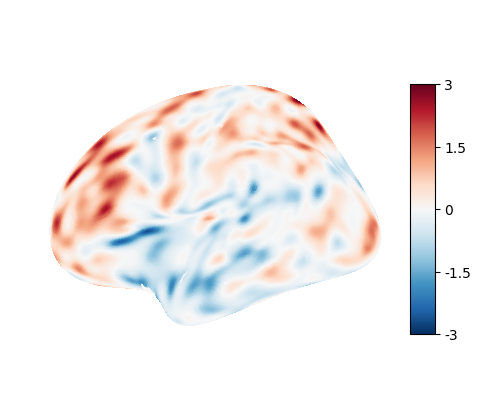

In [2]:
plotting.plot_surf_stat_map(
    surf_mesh=fsavg["infl_left"],
    stat_map=lh_map,
    hemi="left",
    view="lateral"
)

In [ ]:

## plot brain


brain_scrs = []
for hemi in ["rh", "lh"]:
    ## cluster corrected
    fname = results_dir / f"{hemi}.{measure}.{smoothing}.glmdir" / mode / f"cache.th23.pos.sig.ocn.annot"
    brain = Brain("fsaverage", subjects_dir=None, hemi=hemi, views=view, **brain_kwargs)
    brain.add_annotation(str(fname), hemi=hemi, borders=False, color="#C5A059", alpha=alpha)
    brain.add_annotation(parc, borders=True, color="white")
    brain_scr = brain.screenshot()
    brain_scrs.append(brain_scr)

fig, axes = plt.subplots(1, 2, figsize=(7, 5), layout="constrained")
fig.subplots_adjust(hspace=-0.1, wspace=-0.1)
for ax, brain in zip(axes, brain_scrs):
    ax.imshow(brain)
    ax.axis("off")
        
fig.savefig(
            plots_dir / f"brain_doss.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight")


## find the labels
def get_detailed_label(hemi, vertex_index):
    # Load the Destrieux annotation
    labels = mne.read_labels_from_annot(
        subject="fsaverage", 
        parc='aparc.a2009s', 
        hemi=hemi, 
        subjects_dir=None,
        verbose=False
    )
    for label in labels:
        if vertex_index in label.vertices:
            return label.name
    return "Label not found"

peaks = {
    'lh': [],
    'rh': [126390]
}
print(f"{'Hemi':<5} | {'Vertex':<8} | {'Destrieux Label'}")
print("-" * 40)
for hemi, vtx_list in peaks.items():
    for v in vtx_list:
        region = get_detailed_label(hemi, v)
        print(f"{hemi:<5} | {v:<8} | {region}")


## compute stats
for hemi in ["lh", "rh"]:
    for cluster_idx in [1, 2, 3]:
        df_sub = df_thickness.query(f'hemi == "{hemi}" & cluster_idx == {cluster_idx}')
        
        group_co = df_sub[df_sub["group"] == "Controls"]["thickness"]
        group_ti = df_sub[df_sub["group"] == "Tinnitus"]["thickness"]
        t_stat, p_val = stats.ttest_ind(group_ti, group_co)
            
        n1, n2 = len(group_ti), len(group_co)
        var1, var2 = np.var(group_ti, ddof=1), np.var(group_co, ddof=1)
        pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        d = (np.mean(group_ti) - np.mean(group_co)) / pooled_std
            
        print(f"Results for {hemi} and {cluster_idx}:")
        print(f"  Mean (TI): {np.mean(group_ti):.3f}mm | Mean (CO): {np.mean(group_co):.3f}mm")
        print(f"  t-value: {t_stat:.3f}")
        print(f"  Cohen's d: {d:.3f}\n")